In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

#                                             Counter : Strike Physics Engine

#### Reason to elaborate on this topic 

In my free time (when there is a possibility to have one), I really enjoy playing video games, especially Counter-Strike. When I saw that there is a chance I can create a (2D, of course) shooting engine to understand a bit further how the damage is calculated in the game, I took the opportunity to do so.

### Plan: 
1. Weapon - characteristics
2. Introduction to Hitscan - shooting representation
3. What happens when the bullet trajectory hits a wall
4. What happens when the bullet goes through a wallbangable wall? 
5. Utility - grenades, molotov - Newton 

## Weapon 
For the purpose of this project, I will use AK-47 (Kalashnikov) - one of the most known Counter:Strike weapon. It will have damage, bullets and recoil.


The weapon has three properties that change during gameplay:
- **bullets** - starts at 30, decreases by 1 with each shot
- **damage** - stays at 36 HP per hit (simplified)
- **recoil** - starts at 0 and increases by 7 every time you fire

Mathematically, if we fire $n$ shots:

$$
\text{bullets}(n) = 30 - n, \qquad \text{recoil}(n) = 7n
$$

The weapon's state after $n$ shots is just the vector $\mathbf{W}(n) = (30 - n,\; 36,\; 7n)$.


In [2]:
class AK47:
    def __init__(self):
        self.bullets = 30
        self.damage = 36
        self.recoil = 0
        self.shot_recoil = 0 

    def shoot(self):
        if self.bullets > 0:
            self.bullets -= 1
            self.shot_recoil = self.recoil 
            self.recoil += 7
            return True
        return False

ak = AK47()
print(f"Fresh AK-47: bullets={ak.bullets}, damage={ak.damage}, recoil={ak.recoil}")
for i in range(3):

    ak.shoot()    
    print(f"  Shot {i+1}: shot_recoil={ak.shot_recoil}, recoil_after={ak.recoil}, bullets={ak.bullets}")

Fresh AK-47: bullets=30, damage=36, recoil=0
  Shot 1: shot_recoil=0, recoil_after=7, bullets=29
  Shot 2: shot_recoil=7, recoil_after=14, bullets=28
  Shot 3: shot_recoil=14, recoil_after=21, bullets=27


## 2. Introduction to Hitscan - shooting representation

In Counter-Strike, bullets do not actually fly through the air. The moment you click, the game draws an invisible line from your position in the direction you are aiming, checks what that line hits, and applies damage instantly. This is called **hitscan**.

Formally, the bullet is a ray starting at the shooter's position $\vec{P}$ going in direction $\hat{D}$:

$$
\vec{R}(t) = \vec{P} + t\,\hat{D}, \qquad t \geq 0
$$

where $t$ is the distance along the ray. Everything here is 2D, so a position is just a tuple $(x, y)$.

We need a few vector operations to make this work:

**Norm** (length of a vector): $\lVert \vec{v} \rVert = \sqrt{v_x^2 + v_y^2}$

**Normalize** (make it length 1): $\hat{v} = \vec{v}\,/\,\lVert \vec{v} \rVert$

**Rotation** by angle $\theta$:

$$
R(\theta)\,\vec{v} = \begin{pmatrix} v_x\cos\theta - v_y\sin\theta \\ v_x\sin\theta + v_y\cos\theta \end{pmatrix}
$$

And the big one - **ray-wall intersection**. A wall is a line segment from point $\vec{A}$ to point $\vec{B}$, parameterized as $\vec{W}(s) = \vec{A} + s(\vec{B} - \vec{A})$ for $s \in [0,1]$. To find where the ray hits the wall, we solve:

$$
\vec{P} + t\,\hat{D} = \vec{A} + s\,\vec{v}
$$

where $\vec{v} = \vec{B} - \vec{A}$. Using Cramer's rule:

$$
t = \frac{(A_x - P_x)\,v_y - (A_y - P_y)\,v_x}{\hat{D}_x\,v_y - \hat{D}_y\,v_x}
$$

If $t \geq 0$ and $s \in [0,1]$, the bullet hits the wall at point $\vec{H} = \vec{P} + t\,\hat{D}$.

In [3]:
def norm(v):
    return math.sqrt(v[0]**2 + v[1]**2)

def normalize(v):
    m = norm(v)
    return (v[0]/m, v[1]/m) if m > 0 else (0.0, 0.0)

def rotate(v, angle_deg):
    r = math.radians(angle_deg)
    c, s = math.cos(r), math.sin(r)
    return (v[0]*c - v[1]*s, v[0]*s + v[1]*c)

def ray_wall_intersection(origin, direction, wall_start, wall_end):
    d = normalize(direction)
    vx = wall_end[0] - wall_start[0]
    vy = wall_end[1] - wall_start[1]

    det = d[0]*vy - d[1]*vx
    if abs(det) < 1e-10:
        return (False, None, None)

    dx = wall_start[0] - origin[0]
    dy = wall_start[1] - origin[1]

    t = (dx*vy - dy*vx) / det
    s = (dx*d[1] - dy*d[0]) / det

    if t >= 0 and 0 <= s <= 1:
        hit = (origin[0] + d[0]*t, origin[1] + d[1]*t)
        return (True, t, hit)

    return (False, None, None)

# quick sanity check: shoot straight right at a vertical wall
hit, t, point = ray_wall_intersection((0, 5), (1, 0), (10, 0), (10, 10))
print(f"Hit: {hit}, distance: {t}, point: ({point[0]:.1f}, {point[1]:.1f})")

Hit: True, distance: 10.0, point: (10.0, 5.0)


Create test figures

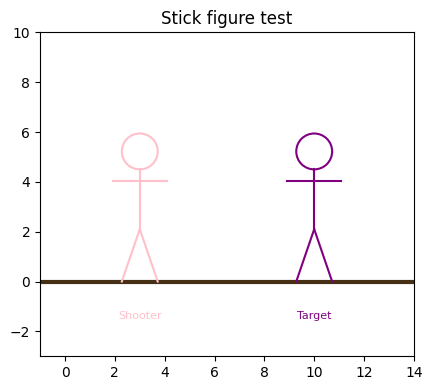

In [4]:
def draw_stickman(ax, x, ground_y, height=6, color='black', label=None):
    head_r = height * 0.12
    body_top = ground_y + height * 0.75
    body_bot = ground_y + height * 0.35
    # head
    circle = plt.Circle((x, body_top + head_r), head_r, fill=False,
                         edgecolor=color, linewidth=1.5, zorder=5)
    ax.add_patch(circle)
    # body
    ax.plot([x, x], [body_top, body_bot], color=color, linewidth=1.5, zorder=5)
    # arms
    ax.plot([x - height*0.18, x + height*0.18],
            [body_top - height*0.08, body_top - height*0.08],
            color=color, linewidth=1.5, zorder=5)
    # legs
    ax.plot([x, x - height*0.12], [body_bot, ground_y], color=color, linewidth=1.5, zorder=5)
    ax.plot([x, x + height*0.12], [body_bot, ground_y], color=color, linewidth=1.5, zorder=5)
    if label:
        ax.text(x, ground_y - 1.5, label, ha='center', fontsize=8, color=color)

# quick test
fig, ax = plt.subplots(figsize=(6, 4))
ax.axhline(y=0, color="#463015", linewidth=3)
draw_stickman(ax, 3, 0, height=6, color='pink', label='Shooter')
draw_stickman(ax, 10, 0, height=6, color='purple', label='Target')
ax.set_xlim(-1, 14)
ax.set_ylim(-3, 10)
ax.set_aspect('equal')
ax.set_title('Stick figure test')
plt.tight_layout()
plt.show()

## 3. What happens when the bullet trajectory hits a wall

When you fire the AK-47, the bullet does not go exactly where you are aiming. Each shot adds recoil, which pushes the direction upward, and there is a random horizontal wobble too.

The recoil model works like this:
- **Vertical offset** grows with each shot: \
\
$\theta_v = \frac{7n}{10}$ degrees  

- **Horizontal offset** is random each time: \
\
$\Theta_h \sim \mathcal{U}(-2, 2)$ degrees

Starting from the original aim direction $\vec{D}$, we apply three transformations in order:

$$
\vec{D} \;\xrightarrow{\text{rotate by }\Theta_h}\; \vec{D}_1 \;\xrightarrow{+\,(0,\;\tan\theta_v)}\; \vec{D}_2 \;\xrightarrow{\text{normalize}}\; \hat{D}_{\text{final}}
$$

Then we cast the ray $\vec{R}(t) = \vec{P} + t\,\hat{D}_{\text{final}}$ and find the closest wall it hits.

But what would happen if we did not check for walls at all? The bullet would just fly forever in a straight line, passing through everything. Let's compare the two approaches side by side.

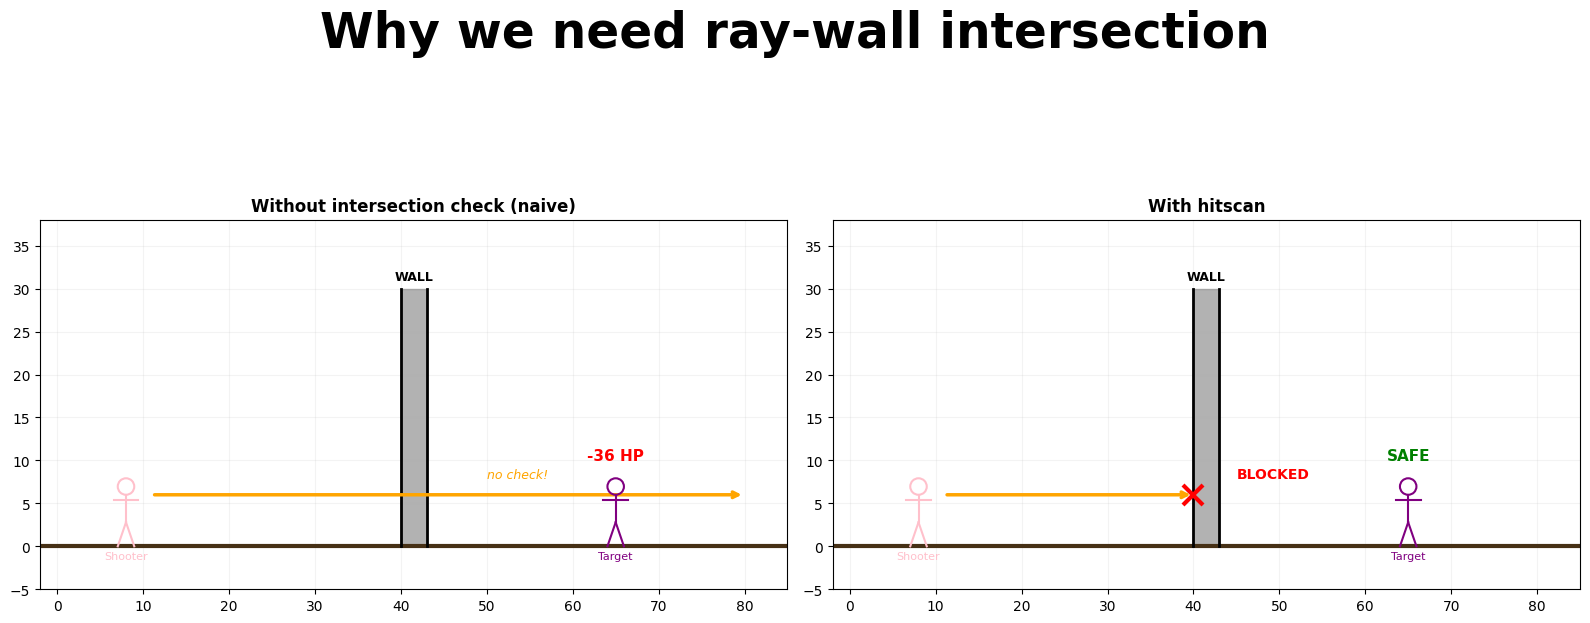

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
ground = 0
wall_x = 40

for ax, title, stops_at_wall in [
    (ax1, 'Without intersection check (naive)', False),
    (ax2, 'With hitscan', True)
]:
    
    ax.axhline(y=ground, color='#463015', linewidth=3)

    ax.fill_between([wall_x, wall_x + 3], ground, 30,
                     color='gray', alpha=0.6)
    ax.plot([wall_x, wall_x], [ground, 30], 'k-', linewidth=2)
    ax.plot([wall_x + 3, wall_x + 3], [ground, 30], 'k-', linewidth=2)
    ax.text(wall_x + 1.5, 31, 'WALL', ha='center', fontsize=9, fontweight='bold')

    draw_stickman(ax, 8, ground, height=8, color='pink', label='Shooter')
    draw_stickman(ax, 65, ground, height=8, color='purple', label='Target')

    aim_y = ground + 6
    if stops_at_wall:
        ax.annotate('', xy=(wall_x, aim_y), xytext=(11, aim_y),
                    arrowprops=dict(arrowstyle='->', color='orange', lw=2.5))
        ax.plot(wall_x, aim_y, 'rx', markersize=14, markeredgewidth=3, zorder=10)
        ax.text(wall_x + 5, aim_y + 2, 'BLOCKED', fontsize=10, color='red', fontweight='bold')
        ax.text(65, ground + 10, 'SAFE', fontsize=11, color='green', fontweight='bold', ha='center')
    else:
        ax.annotate('', xy=(80, aim_y), xytext=(11, aim_y),
                    arrowprops=dict(arrowstyle='->', color='orange', lw=2.5))
        ax.text(65, ground + 10, '-36 HP', fontsize=11, color='red', fontweight='bold', ha='center')
        ax.text(50, aim_y + 2, 'no check!', fontsize=9, color='orange', style='italic')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(-2, 85)
    ax.set_ylim(-5, 38)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.15)

plt.suptitle('Why we need ray-wall intersection', fontsize=35, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

If we fire many shots, the hit points $\{\vec{H}_1, \vec{H}_2, \ldots, \vec{H}_n\}$ form a spray pattern. We can measure how tight or spread out the pattern is with the **centroid**:

$$
\vec{C}_n = \frac{1}{n}\sum_{i=1}^{n} \vec{H}_i
$$

Because the vertical recoil grows linearly ($7n$), the spray spreads roughly as $\sigma^2 \propto n^2$ .This forms a cone shape.

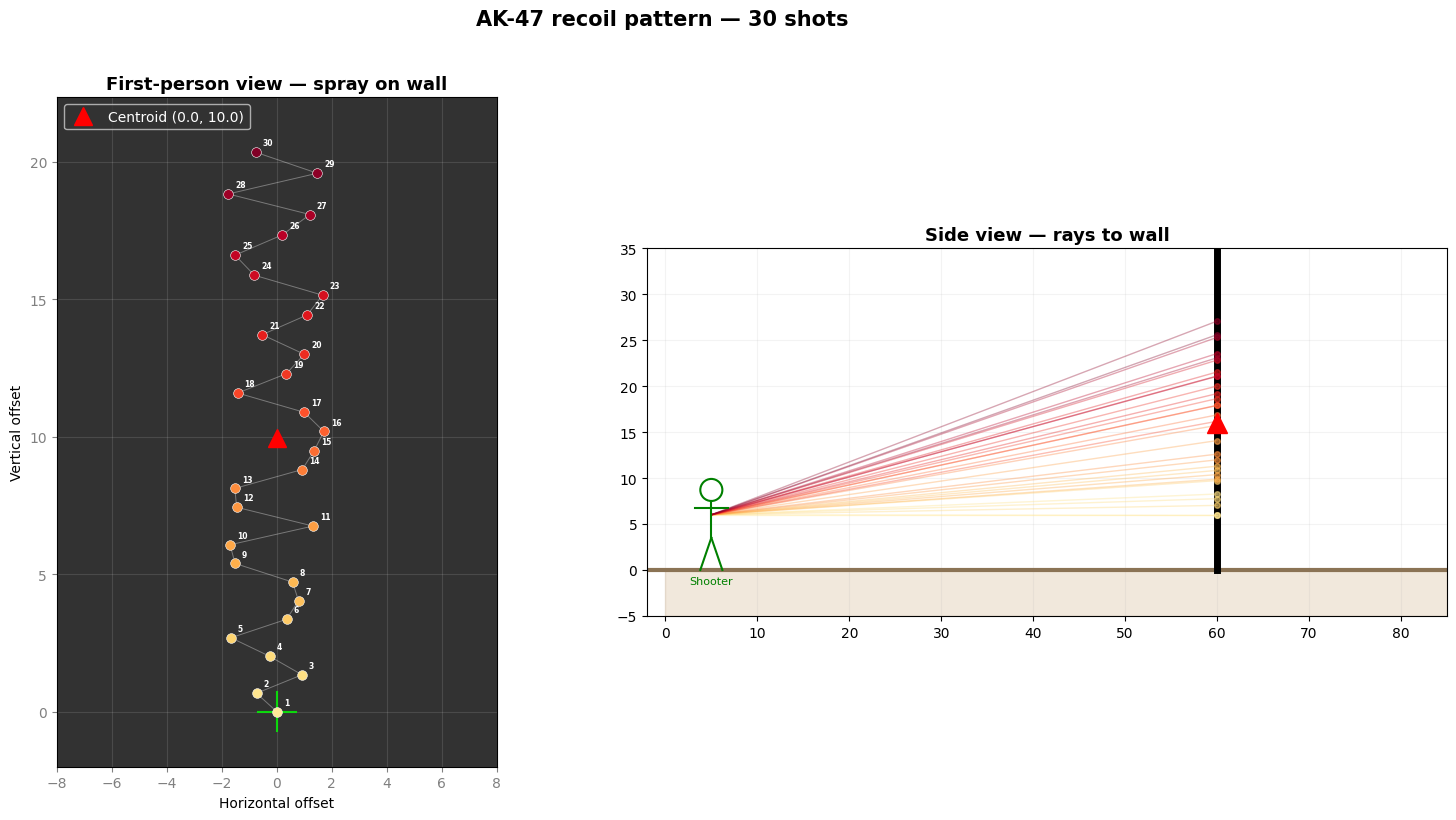

In [6]:
def visualize_recoil_pattern(n_shots=30):
    D = 55.0
    wall_x = 60
    P = (5, 6)
    ground_y = 0
    ak = AK47()

    fp_hits = []      # (h_offset, v_offset) on wall face
    side_hits = []    # (x, y) world coords

    for i in range(n_shots):
        if not ak.shoot():
            break

        if ak.shot_recoil == 0:
            theta_v, theta_h = 0.0, 0.0
        else:
            theta_v = ak.shot_recoil / 10.0
            theta_h = np.random.uniform(-2.0, 2.0)

        # first-person offsets on wall at distance D
        h_off = D * math.tan(math.radians(theta_h))
        v_off = D * math.tan(math.radians(theta_v))
        fp_hits.append((h_off, v_off))

        # side-view ray (same direction, intersect vertical wall)
        if ak.shot_recoil == 0:
            d = normalize((1, 0))
        else:
            d = rotate((1, 0), theta_h)
            d = (d[0], d[1] + math.tan(math.radians(theta_v)))
            d = normalize(d)

        hit, t, pt = ray_wall_intersection(P, d, (wall_x, 0), (wall_x, 40))
        if hit and pt:
            side_hits.append(pt)

    # ---- figure ----
    fig, (ax_fp, ax_side) = plt.subplots(1, 2, figsize=(16, 8))

    # === LEFT: first-person spray on the wall ===
    wall_hw = 8
    max_v = max(h[1] for h in fp_hits) if fp_hits else 14
    wall_hh = max_v + 2
    ax_fp.fill_between([-wall_hw, wall_hw], -2, wall_hh,
                        color='#4a4a4a', alpha=0.25)

    # crosshair
    ch = 0.7
    ax_fp.plot([-ch, ch], [0, 0], color='lime', lw=1.5, alpha=0.8)
    ax_fp.plot([0, 0], [-ch, ch], color='lime', lw=1.5, alpha=0.8)

    colors = plt.cm.YlOrRd(np.linspace(0.15, 1.0, len(fp_hits)))

    # spray path line
    if fp_hits:
        ax_fp.plot([h[0] for h in fp_hits], [h[1] for h in fp_hits],
                   '-', color='white', lw=0.7, alpha=0.35)

    for idx, (ho, vo) in enumerate(fp_hits):
        ax_fp.plot(ho, vo, 'o', color=colors[idx], markersize=7,
                   markeredgecolor='white', markeredgewidth=0.4, zorder=5)
        ax_fp.text(ho + 0.25, vo + 0.25, str(idx + 1),
                   fontsize=5.5, color='white', fontweight='bold', zorder=6)

    if fp_hits:
        cx = np.mean([h[0] for h in fp_hits])
        cy = np.mean([h[1] for h in fp_hits])
        ax_fp.plot(cx, cy, 'r^', markersize=13, zorder=10,
                   label=f'Centroid ({cx:.1f}, {cy:.1f})')
        ax_fp.legend(fontsize=10, loc='upper left',
                     facecolor='#333', labelcolor='white')

    ax_fp.set_xlim(-wall_hw, wall_hw)
    ax_fp.set_ylim(-2, wall_hh)
    ax_fp.set_title('First-person view — spray on wall', fontsize=13, fontweight='bold')
    ax_fp.set_xlabel('Horizontal offset')
    ax_fp.set_ylabel('Vertical offset')
    ax_fp.set_facecolor('#2a2a2a')
    ax_fp.tick_params(colors='gray')
    ax_fp.grid(True, alpha=0.12, color='white')
    ax_fp.set_aspect('equal')

    # === RIGHT: side view ===
    ax_side.axhline(y=ground_y, color='#8B7355', linewidth=3)
    ax_side.fill_between([0, 85], -5, ground_y, color='#D2B48C', alpha=0.3)
    ax_side.plot([wall_x, wall_x], [ground_y, 35], 'k-', linewidth=5)

    draw_stickman(ax_side, P[0], ground_y, height=10, color='green', label='Shooter')

    colors_s = plt.cm.YlOrRd(np.linspace(0.15, 1.0, len(side_hits)))
    for idx, h in enumerate(side_hits):
        ax_side.plot([P[0], h[0]], [P[1], h[1]],
                     color=colors_s[idx], lw=1, alpha=0.35)
        ax_side.plot(h[0], h[1], 'o', color=colors_s[idx], markersize=4, alpha=0.6)

    if side_hits:
        cx_s = np.mean([h[0] for h in side_hits])
        cy_s = np.mean([h[1] for h in side_hits])
        ax_side.plot(cx_s, cy_s, 'r^', markersize=14, zorder=10)

    ax_side.set_title('Side view — rays to wall', fontsize=13, fontweight='bold')
    ax_side.set_xlim(-2, 85)
    ax_side.set_ylim(-5, 35)
    ax_side.grid(True, alpha=0.15)
    ax_side.set_aspect('equal')

    plt.suptitle(f'AK-47 recoil pattern — {n_shots} shots',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

visualize_recoil_pattern(30)